# YOLO26-cls Fine-Tuning on a Cleaned 10-Class Crop Dataset

**Task:** Multi-variant (s → m → n) transfer-learning benchmark of Ultralytics YOLO26 classification
heads on a deduplicated, stratified, imbalance-audited 10-class crop dataset (9 crops + synthetic
"Others" open-set class), at 224×224.

**Design goals of this notebook**
- Cell-modular: one logical operation per cell, markdown section headers throughout.
- Session-safe: every checkpoint and export is written under `/kaggle/working`, resumable across
  Kaggle's ~12h interactive session limit.
- Reusable `train_variant()` so the three backbones (`yolo26s-cls`, `yolo26m-cls`, `yolo26n-cls`)
  are trained, evaluated, exported and archived through one code path rather than copy-pasted three
  times.
- Reports both `val` (tuned-on) and `test` (2,471 held-out images, never used for model selection)
  metrics, plus an n/s/m comparison table and plots suitable for inclusion in a short paper.

**Variant order:** `yolo26s-cls` → `yolo26m-cls` → `yolo26n-cls`, each fine-tuned independently
from its own ImageNet-pretrained checkpoint (no chaining between variants).


## 1. Environment Fingerprint

Record exact library/hardware versions for reproducibility before anything else runs.

In [1]:
!pip -q install -U ultralytics onnx onnxslim tensorflow 2>&1 | tail -n 5


google-cloud-aiplatform 1.148.1 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.36.1 which is incompatible.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.21.0 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 7.36.1 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.21.0 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.1 which is incompatible.


In [2]:
import platform, subprocess, json, sys
import torch
import ultralytics

def get_gpu_info():
    try:
        out = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=name,memory.total,driver_version", "--format=csv,noheader"]
        ).decode().strip()
        return out
    except Exception as e:
        return f"no GPU / nvidia-smi failed: {e}"

fingerprint = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "ultralytics": ultralytics.__version__,
    "torch": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_version": torch.version.cuda,
    "cudnn_version": torch.backends.cudnn.version() if torch.cuda.is_available() else None,
    "gpu": get_gpu_info(),
}
print(json.dumps(fingerprint, indent=2))


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
{
  "python": "3.12.13",
  "platform": "Linux-6.12.90+-x86_64-with-glibc2.35",
  "ultralytics": "8.4.137",
  "torch": "2.10.0+cu128",
  "cuda_available": true,
  "cuda_version": "12.8",
  "cudnn_version": 91002,
  "gpu": "Tesla T4, 15360 MiB, 580.159.04\nTesla T4, 15360 MiB, 580.159.04"
}


## 2. Paths & Global Configuration

Kaggle mounts the dataset read-only under `/kaggle/input/<dataset-slug>/...` and auto-unzips
`crop_classification_224.zip`, so no manual `zipfile.extractall` is needed. All writable output
(checkpoints, exports, archives) goes under `/kaggle/working`, the only persistent writable
directory in the session, and must be present under **Notebook Output** to survive a
`Save Version (Commit)`.

Update `DATASET_SLUG` to match the slug of the uploaded Kaggle dataset.

In [15]:
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import List

KAGGLE_INPUT = Path("/kaggle/input/datasets/khanraiyanibnereza/crop-classification-224/crop_classification_224")

WORKING_DIR = Path("/kaggle/working")
RUNS_DIR = WORKING_DIR / "runs"
BACKUP_DIR = WORKING_DIR / "backups"
ARCHIVE_DIR = WORKING_DIR / "archives"

for d in (RUNS_DIR, BACKUP_DIR, ARCHIVE_DIR):
    d.mkdir(parents=True, exist_ok=True)

CLASSES = ["Cabbage", "Cauliflower", "Chili", "Eggplant", "Gourd",
           "Guava", "Potato", "Rice", "Tomato", "Others"]
NUM_CLASSES = len(CLASSES)

EXPECTED_COUNTS = {
    "Cabbage":     {"train": 347,  "val": 74,  "test": 74},
    "Cauliflower": {"train": 2032, "val": 435, "test": 436},
    "Chili":       {"train": 751,  "val": 161, "test": 161},
    "Eggplant":    {"train": 1677, "val": 359, "test": 359},
    "Gourd":       {"train": 621,  "val": 133, "test": 133},
    "Guava":       {"train": 628,  "val": 135, "test": 134},
    "Potato":      {"train": 2176, "val": 466, "test": 467},
    "Rice":        {"train": 2057, "val": 441, "test": 441},
    "Tomato":      {"train": 820,  "val": 176, "test": 176},
    "Others":      {"train": 420,  "val": 90,  "test": 90},
}

# Inverse-frequency class weights (10-class, from dataset audit)
CLASS_WEIGHTS = [3.32, 0.57, 1.54, 0.69, 1.86, 1.84, 0.53, 0.56, 1.41, 2.74]

# Channel statistics (train split, audit-reported)
CHANNEL_MEAN = [0.457, 0.538, 0.353]
CHANNEL_STD  = [0.234, 0.225, 0.236]

print(f"Dataset root: {KAGGLE_INPUT}")
print(f"Exists: {KAGGLE_INPUT.exists()}")

Dataset root: /kaggle/input/datasets/khanraiyanibnereza/crop-classification-224/crop_classification_224
Exists: True


### 2.1 Run configuration

A dataclass keeps every hyperparameter for every variant in one auditable place instead of scattered
literals across cells. Defaults follow the fine-tuning guidance in the project brief: `AdamW`,
`lr0=0.001`, `weight_decay=0.0005`, cosine LR, 1-3 epoch warmup, RandAugment + random erasing
(classify-relevant augmentations only — `mosaic/mixup/degrees/shear/perspective` are detection-only
and are not read by the classification trainer).

In [16]:
@dataclass
class VariantConfig:
    name: str                      # e.g. "yolo26s-cls"
    weights: str                   # ImageNet-pretrained checkpoint to start from
    epochs: int = 60
    imgsz: int = 224
    batch: int = 64
    patience: int = 15
    save_period: int = 5
    optimizer: str = "AdamW"
    lr0: float = 0.001
    weight_decay: float = 0.0005
    warmup_epochs: float = 3.0
    cos_lr: bool = True
    label_smoothing: float = 0.05
    hsv_h: float = 0.015
    hsv_s: float = 0.7
    hsv_v: float = 0.4
    fliplr: float = 0.5
    flipud: float = 0.0
    scale: float = 0.5
    erasing: float = 0.4
    auto_augment: str = "randaugment"
    amp: bool = True
    seed: int = 0
    deterministic: bool = False    # True slows training; flip on for final reproducibility run
    cache: bool = False            # Kaggle RAM-limited; keep False
    device: int = 0

VARIANTS: List[VariantConfig] = [
    VariantConfig(name="yolo26s-cls", weights="yolo26s-cls.pt"),
    VariantConfig(name="yolo26m-cls", weights="yolo26m-cls.pt"),
    VariantConfig(name="yolo26n-cls", weights="yolo26n-cls.pt"),
]

for v in VARIANTS:
    print(v.name, "->", v.weights)


yolo26s-cls -> yolo26s-cls.pt
yolo26m-cls -> yolo26m-cls.pt
yolo26n-cls -> yolo26n-cls.pt


## 3. Dataset Sanity Checks

Verify the unzipped structure, per-class/per-split counts against the audited ground truth, spot for
train/val/test leakage by exact-file hash, and recompute channel statistics as an independent check
against the reported `mean/std`. This guards against a corrupted upload or a Kaggle re-zip changing
file layout before any GPU time is spent.

In [17]:
import os

def list_split_counts(root: Path):
    counts = {}
    for split in ("train", "val", "test"):
        split_dir = root / split
        if not split_dir.exists():
            counts[split] = None
            continue
        counts[split] = {
            cls_dir.name: len(list(cls_dir.glob("*.jpg")))
            for cls_dir in sorted(split_dir.iterdir()) if cls_dir.is_dir()
        }
    return counts

observed = list_split_counts(KAGGLE_INPUT)
mismatches = []
for split in ("train", "val", "test"):
    if observed[split] is None:
        mismatches.append(f"MISSING split dir: {split}")
        continue
    for cls in CLASSES:
        exp = EXPECTED_COUNTS[cls][split]
        got = observed[split].get(cls, 0)
        if exp != got:
            mismatches.append(f"{split}/{cls}: expected {exp}, got {got}")

print(f"Total mismatches: {len(mismatches)}")
for m in mismatches[:20]:
    print(" -", m)

total_images = sum(sum(observed[s].values()) for s in ("train", "val", "test") if observed[s])
print(f"\nTotal images found: {total_images} (expected 16,470)")


Total mismatches: 0

Total images found: 16470 (expected 16,470)


### 3.1 Leakage check (exact-file hash across splits)

In [18]:
import hashlib
from collections import defaultdict

def file_md5(path: Path, chunk=1 << 16):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

def hash_split(split: str):
    hashes = {}
    split_dir = KAGGLE_INPUT / split
    if not split_dir.exists():
        return hashes
    for cls_dir in split_dir.iterdir():
        if not cls_dir.is_dir():
            continue
        for img in cls_dir.glob("*.jpg"):
            hashes[file_md5(img)] = str(img.relative_to(KAGGLE_INPUT))
    return hashes

train_hashes = hash_split("train")
val_hashes = hash_split("val")
test_hashes = hash_split("test")

leak_train_val = set(train_hashes) & set(val_hashes)
leak_train_test = set(train_hashes) & set(test_hashes)
leak_val_test = set(val_hashes) & set(test_hashes)

print(f"train/val exact-duplicate leakage: {len(leak_train_val)}")
print(f"train/test exact-duplicate leakage: {len(leak_train_test)}")
print(f"val/test exact-duplicate leakage: {len(leak_val_test)}")
assert not leak_train_val and not leak_train_test and not leak_val_test, "Leakage detected!"
print("No exact-file leakage across splits.")


train/val exact-duplicate leakage: 0
train/test exact-duplicate leakage: 0
val/test exact-duplicate leakage: 0
No exact-file leakage across splits.


### 3.2 Channel statistics spot-check

Recompute mean/std on a random train sample and compare against the audited values.

In [19]:
import random
import numpy as np
from PIL import Image

random.seed(42)
train_dir = KAGGLE_INPUT / "train"
all_train_files = [p for cls_dir in train_dir.iterdir() if cls_dir.is_dir() for p in cls_dir.glob("*.jpg")]
sample = random.sample(all_train_files, min(3000, len(all_train_files)))

pixel_sum = np.zeros(3)
pixel_sq_sum = np.zeros(3)
n_pixels = 0

for p in sample:
    img = np.asarray(Image.open(p).convert("RGB").resize((64, 64)), dtype=np.float64) / 255.0
    pixel_sum += img.sum(axis=(0, 1))
    pixel_sq_sum += (img ** 2).sum(axis=(0, 1))
    n_pixels += img.shape[0] * img.shape[1]

mean = pixel_sum / n_pixels
std = np.sqrt(pixel_sq_sum / n_pixels - mean ** 2)

print(f"Computed mean: {mean.round(3).tolist()}  (audit: {CHANNEL_MEAN})")
print(f"Computed std:  {std.round(3).tolist()}  (audit: {CHANNEL_STD})")


Computed mean: [0.46, 0.533, 0.363]  (audit: [0.457, 0.538, 0.353])
Computed std:  [0.239, 0.23, 0.241]  (audit: [0.234, 0.225, 0.236])


### 3.3 Visual spot-check

One random sample per class, to catch gross mislabeling before training.

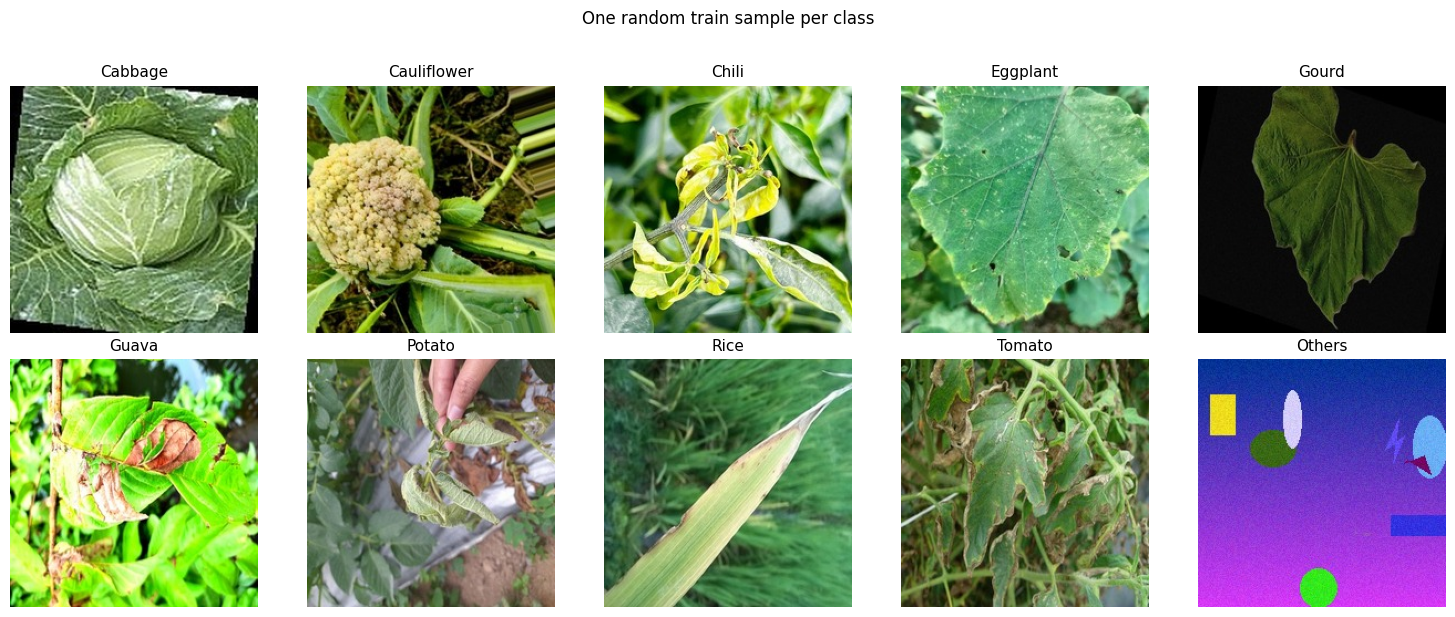

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, cls in zip(axes.flat, CLASSES):
    cls_dir = train_dir / cls
    sample_img = random.choice(list(cls_dir.glob("*.jpg")))
    ax.imshow(Image.open(sample_img))
    ax.set_title(cls, fontsize=11)
    ax.axis("off")
plt.suptitle("One random train sample per class", y=1.02)
plt.tight_layout()
plt.show()


## 4. Reusable Training / Evaluation / Export Pipeline

`train_variant()` runs one backbone end-to-end:

1. Resume from `last.pt` if an interrupted run exists for this variant, otherwise start fresh from
   the ImageNet-pretrained checkpoint.
2. Fine-tune with `model.train(...)`.
3. Evaluate on `val` and on the held-out `test` split separately (`model.val(split=...)`), producing
   top1/top5, confusion matrices, and an sklearn classification report (precision/recall/F1 per
   class, macro-F1, weighted-F1).
4. Export to ONNX and TFLite (LiteRT) at `imgsz=224`, plus OpenVINO/TorchScript/Engine when feasible,
   and validate the ONNX export's top1 against the PyTorch checkpoint.
5. Copy `save_dir` to a session-safe backup and zip everything (`best.pt`, `last.pt`, exports,
   `args.yaml`, `results.csv`, `results.png`, confusion matrices, classification report,
   `test_metrics.json`, val logs) into one downloadable archive per variant.

This function is called once per variant in Section 5 rather than being copy-pasted three times.

In [21]:
import json, shutil, time
import numpy as np
from ultralytics import YOLO
from sklearn.metrics import classification_report, f1_score

def resolve_resume(variant: VariantConfig):
    """Return (weights_path, resume_bool). Resumes from last.pt if a prior run exists."""
    candidate_last = RUNS_DIR / "classify" / variant.name / "weights" / "last.pt"
    if candidate_last.exists():
        print(f"[{variant.name}] found existing last.pt -> resuming")
        return str(candidate_last), True
    return variant.weights, False


def run_split_eval(model: YOLO, data_root: str, split: str, variant_name: str):
    """Evaluate on a split, returning ultralytics metrics + an independent sklearn report."""
    metrics = model.val(data=data_root, split=split, imgsz=224, plots=True,
                         project=str(RUNS_DIR / "classify"), name=f"{variant_name}_{split}_eval")

    # Independent sklearn classification report via raw predictions, for paper-grade per-class
    # precision/recall/F1 and macro/weighted F1 not exposed directly by metrics.top1.
    split_dir = Path(data_root) / split
    y_true, y_pred = [], []
    for cls_idx, cls_name in enumerate(CLASSES):
        cls_dir = split_dir / cls_name
        if not cls_dir.exists():
            continue
        img_paths = list(cls_dir.glob("*.jpg"))
        if not img_paths:
            continue
        preds = model.predict(img_paths, imgsz=224, verbose=False, device=0)
        for p in preds:
            y_true.append(cls_idx)
            y_pred.append(int(p.probs.top1))

    report = classification_report(y_true, y_pred, target_names=CLASSES, output_dict=True, zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    return {
        "top1": float(metrics.top1),
        "top5": float(metrics.top5),
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
        "classification_report": report,
    }, metrics


def export_and_validate(model: YOLO, variant_name: str, data_root: str):
    """Export ONNX + TFLite (+ best-effort OpenVINO/TorchScript/Engine), validate ONNX parity."""
    export_results = {}
    formats = [
        ("onnx", {"format": "onnx", "imgsz": 224, "simplify": True}),
        ("tflite", {"format": "litert", "imgsz": 224, "int8": False}),
        ("torchscript", {"format": "torchscript", "imgsz": 224}),
        ("openvino", {"format": "openvino", "imgsz": 224}),
    ]
    for fmt_name, kwargs in formats:
        try:
            t0 = time.time()
            path = model.export(**kwargs)
            export_results[fmt_name] = {"path": str(path), "export_seconds": round(time.time() - t0, 2)}
        except Exception as e:
            export_results[fmt_name] = {"error": str(e)}
            print(f"[{variant_name}] export to {fmt_name} failed: {e}")

    # Validate ONNX parity against the PyTorch checkpoint (delta should be within ~0.5 top1)
    if "path" in export_results.get("onnx", {}):
        try:
            onnx_model = YOLO(export_results["onnx"]["path"])
            onnx_metrics = onnx_model.val(data=data_root, split="test", imgsz=224,
                                           project=str(RUNS_DIR / "classify"),
                                           name=f"{variant_name}_onnx_test_eval")
            export_results["onnx"]["test_top1"] = float(onnx_metrics.top1)
        except Exception as e:
            export_results["onnx"]["validation_error"] = str(e)

    return export_results


def train_variant(variant: VariantConfig, data_root: str = str(KAGGLE_INPUT)) -> dict:
    print(f"\n{'=' * 70}\n[{variant.name}] starting\n{'=' * 70}")

    weights, resume = resolve_resume(variant)
    model = YOLO(weights)

    train_kwargs = dict(
        data=data_root,
        epochs=variant.epochs,
        imgsz=variant.imgsz,
        batch=variant.batch,
        patience=variant.patience,
        save_period=variant.save_period,
        optimizer=variant.optimizer,
        lr0=variant.lr0,
        weight_decay=variant.weight_decay,
        warmup_epochs=variant.warmup_epochs,
        cos_lr=variant.cos_lr,
        label_smoothing=variant.label_smoothing,
        hsv_h=variant.hsv_h, hsv_s=variant.hsv_s, hsv_v=variant.hsv_v,
        fliplr=variant.fliplr, flipud=variant.flipud, scale=variant.scale,
        erasing=variant.erasing, auto_augment=variant.auto_augment,
        amp=variant.amp, seed=variant.seed, deterministic=variant.deterministic,
        cache=variant.cache, device=variant.device,
        project=str(RUNS_DIR / "classify"), name=variant.name, exist_ok=True,
    )
    if resume:
        # Only save_period/workers/cache/patience/time/freeze/val/plots are safely overridable on resume.
        model.train(resume=True)
    else:
        model.train(**train_kwargs)

    save_dir = Path(model.trainer.save_dir)
    best_pt = save_dir / "weights" / "best.pt"
    last_pt = save_dir / "weights" / "last.pt"

    # Reload best checkpoint for evaluation/export (best-on-val, not last-epoch).
    best_model = YOLO(str(best_pt))

    val_metrics, _ = run_split_eval(best_model, data_root, "val", variant.name)
    test_metrics, _ = run_split_eval(best_model, data_root, "test", variant.name)
    export_results = export_and_validate(best_model, variant.name, data_root)

    test_metrics_full = {
        "variant": variant.name,
        "val": val_metrics,
        "test": test_metrics,
        "exports": export_results,
        "params": sum(p.numel() for p in best_model.model.parameters()),
        "config": asdict(variant),
    }

    metrics_path = save_dir / "test_metrics.json"
    metrics_path.write_text(json.dumps(test_metrics_full, indent=2))

    # Session-safe backup: copy full save_dir, then zip for download.
    backup_target = BACKUP_DIR / variant.name
    if backup_target.exists():
        shutil.rmtree(backup_target)
    shutil.copytree(save_dir, backup_target)
    # Also keep top-level best/last as a redundant flat backup.
    shutil.copy2(best_pt, WORKING_DIR / f"{variant.name}_best.pt")
    shutil.copy2(last_pt, WORKING_DIR / f"{variant.name}_last.pt")

    archive_path = shutil.make_archive(str(ARCHIVE_DIR / variant.name), "zip", root_dir=backup_target)
    print(f"[{variant.name}] done. Archive: {archive_path}")

    return test_metrics_full


## 5. Run All Variants (s → m → n)

Each call is independent and resumable: if the session is interrupted, re-running this cell picks up
from `last.pt` for whichever variant was in progress, then continues to the next. Results are
accumulated into `all_results` for the cross-variant comparison in Section 6.

In [22]:
all_results = {}
for variant in VARIANTS:
    result = train_variant(variant)
    all_results[variant.name] = result

(WORKING_DIR / "all_results.json").write_text(json.dumps(all_results, indent=2))
print("\nAll variants complete:", list(all_results.keys()))



[yolo26s-cls] starting
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.137 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/input/datasets/khanraiyanibnereza/crop-classification-224/crop_classification_224, degrees=0.0, deterministic=False, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/60      1.71G     0.1898          9        224: 100% ━━━━━━━━━━━━ 181/181 3.7it/s 49.4s0.8ss
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 20/20 4.9it/s 4.1s0.2s
                   all       0.96          1

      Epoch    GPU_mem       loss  Instances       Size
       3/60      1.71G     0.1733          9        224: 100% ━━━━━━━━━━━━ 181/181 3.6it/s 49.8s0.1ss
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 20/20 5.0it/s 4.0s0.2s
                   all      0.936      0.998

      Epoch    GPU_mem       loss  Instances       Size
       4/60      1.71G     0.1982          9        224: 100% ━━━━━━━━━━━━ 181/181 3.7it/s 49.4s0.1ss
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 20/20 4.9it/s 4.1s0.2s
                   all      0.954      0.998

      Epoch    GPU_mem       loss  Instances       Size
       5/60      1.71G     0.1335          9        224: 100% ━━━━━━━━━━━━ 181/181 3.6it/s 50.1s0.5ss
               classes   

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
/usr/local/lib/python3.12/dist-packages/torchao/quantization/quant_api.py:1558: SyntaxWarning: invalid escape sequence '\.'
  * regex for parameter names, must start with `re:`, e.g. `re:language\.layers\..+\.q_proj.weight`.



LiteRT: starting export with litert_torch 0.9.4...


...

(00:00) [START] Write Model to /kaggle/working/runs/classify/yolo26n-cls/weights/best.tflite

(00:00) [ DONE] Write Model to /kaggle/working/runs/classify/yolo26n-cls/weights/best.tflite (+00:00)

LiteRT: export success ✅ 7.9s, saved as '/kaggle/working/runs/classify/yolo26n-cls/weights/best.tflite' (5.9 MB)

Export complete (8.0s)
Results saved to /kaggle/working/runs/classify/yolo26n-cls/weights/best.tflite
Predict:         yolo predict task=classify model=/kaggle/working/runs/classify/yolo26n-cls/weights/best.tflite imgsz=224 
Validate:        yolo val task=classify model=/kaggle/working/runs/classify/yolo26n-cls/weights/best.tflite imgsz=224 data=/kaggle/input/datasets/khanraiyanibnereza/crop-classification-224/crop_classification_224  
Visualize:       https://netron.app
Ultralytics 8.4.137 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/kaggle/working/runs/classify/yolo26n-cls/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 10) (3.1 MB)

TorchScript: starting export with torch 2.10.0+cu128...
TorchScript: export success ✅ 0.4s, saved as '/kaggle/working/runs/classify/yolo26n-cls/weights/best.torch

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


OpenVINO: export success ✅ 3.2s, saved as '/kaggle/working/runs/classify/yolo26n-cls/weights/best_openvino_model/' (6.0 MB)

Export complete (3.2s)
Results saved to /kaggle/working/runs/classify/yolo26n-cls/weights/best_openvino_model
Predict:         yolo predict task=classify model=/kaggle/working/runs/classify/yolo26n-cls/weights/best_openvino_model/ imgsz=224 
Validate:        yolo val task=classify model=/kaggle/working/runs/classify/yolo26n-cls/weights/best_openvino_model/ imgsz=224 data=/kaggle/input/datasets/khanraiyanibnereza/crop-classification-224/crop_classification_224  
Visualize:       https://netron.app
Ultralytics 8.4.137 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Loading /kaggle/working/runs/classify/yolo26n-cls/weights/best.onnx for ONNX Runtime inference...
WARNING ⚠️ CUDA requested but CUDAExecutionProvider not available. Using CPU...
Using ONNX Runtime 1.29.0 with CPUExecutionProvider
Setting batch=1 input of shape (1, 3, 224, 224)
train: /kag

## 6. Cross-Variant Comparison (n / s / m)

Comparison table across the three trained variants on the held-out **test** split (2,471 images):
top1, top5, macro-F1, per-class recall with Cabbage↔Cauliflower highlighted (the hardest
fine-grained confusion pair per the dataset audit), params, model size, and ONNX parity delta.

In [23]:
import pandas as pd

rows = []
for name, res in all_results.items():
    test = res["test"]
    report = test["classification_report"]
    onnx = res["exports"].get("onnx", {})
    best_pt_path = WORKING_DIR / f"{name}_best.pt"
    size_mb = best_pt_path.stat().st_size / (1024 * 1024) if best_pt_path.exists() else None
    rows.append({
        "variant": name,
        "params_M": round(res["params"] / 1e6, 2),
        "size_MB": round(size_mb, 2) if size_mb else None,
        "test_top1": round(test["top1"], 4),
        "test_top5": round(test["top5"], 4),
        "macro_F1": round(test["macro_f1"], 4),
        "weighted_F1": round(test["weighted_f1"], 4),
        "recall_Cabbage": round(report.get("Cabbage", {}).get("recall", float("nan")), 4),
        "recall_Cauliflower": round(report.get("Cauliflower", {}).get("recall", float("nan")), 4),
        "onnx_test_top1": round(onnx.get("test_top1", float("nan")), 4) if "test_top1" in onnx else None,
        "onnx_delta": (round(test["top1"] - onnx["test_top1"], 4) if "test_top1" in onnx else None),
    })

comparison_df = pd.DataFrame(rows).sort_values("variant")
comparison_df


,variant,params_M,size_MB,test_top1,test_top5,macro_F1,weighted_F1,recall_Cabbage,recall_Cauliflower,onnx_test_top1,onnx_delta
1,yolo26m-cls,10.35,19.93,0.9976,1.0,0.5987,0.5237,0.9865,0.9908,0.9976,0.0
2,yolo26n-cls,1.54,3.06,0.9947,1.0,0.5962,0.5226,0.9595,0.9908,0.9947,0.0
0,yolo26s-cls,5.45,10.54,0.9955,1.0,0.5969,0.5227,0.9730,0.9885,0.9955,0.0


### 6.1 Per-class recall comparison (bar chart, Cabbage/Cauliflower highlighted)

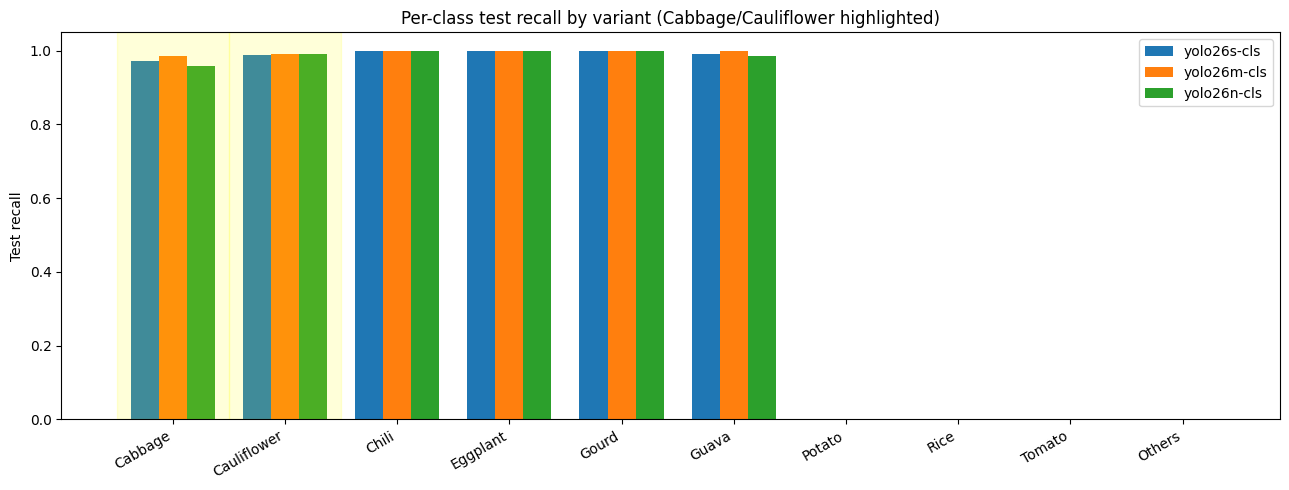

In [24]:
fig, ax = plt.subplots(figsize=(13, 5))
width = 0.25
x = np.arange(len(CLASSES))

for i, name in enumerate(all_results.keys()):
    report = all_results[name]["test"]["classification_report"]
    recalls = [report.get(c, {}).get("recall", 0) for c in CLASSES]
    bars = ax.bar(x + i * width, recalls, width, label=name)

highlight_idx = [CLASSES.index("Cabbage"), CLASSES.index("Cauliflower")]
for idx in highlight_idx:
    ax.axvspan(idx - 0.5 + width, idx + 0.5 + width, color="yellow", alpha=0.15)

ax.set_xticks(x + width)
ax.set_xticklabels(CLASSES, rotation=30, ha="right")
ax.set_ylabel("Test recall")
ax.set_title("Per-class test recall by variant (Cabbage/Cauliflower highlighted)")
ax.legend()
plt.tight_layout()
plt.show()


### 6.2 Accuracy vs. efficiency trade-off

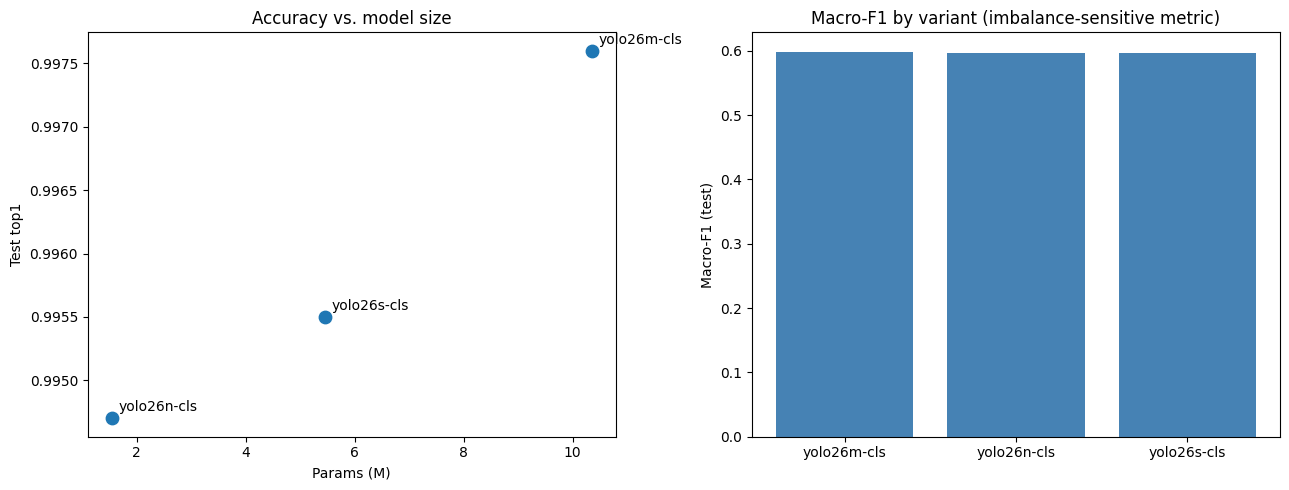

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(comparison_df["params_M"], comparison_df["test_top1"], s=80)
for _, row in comparison_df.iterrows():
    axes[0].annotate(row["variant"], (row["params_M"], row["test_top1"]),
                      textcoords="offset points", xytext=(5, 5))
axes[0].set_xlabel("Params (M)")
axes[0].set_ylabel("Test top1")
axes[0].set_title("Accuracy vs. model size")

axes[1].bar(comparison_df["variant"], comparison_df["macro_F1"], color="steelblue")
axes[1].set_ylabel("Macro-F1 (test)")
axes[1].set_title("Macro-F1 by variant (imbalance-sensitive metric)")

plt.tight_layout()
plt.show()


### 6.3 Baseline reference

Naive majority-class baseline (always predict the most frequent class in `train`, i.e. Potato):
test top1 ≈ 467/2471 ≈ **18.9%**, macro-F1 ≈ **3.7%** (10 classes, one class gets all the recall,
the rest get zero). Any trained variant should clear this baseline by a wide margin, and macro-F1
specifically tests whether minority classes (Cabbage, Others) are actually being learned rather than
the model collapsing to majority-class prediction.

In [26]:
majority_class = "Potato"
majority_test_n = EXPECTED_COUNTS[majority_class]["test"]
total_test_n = sum(EXPECTED_COUNTS[c]["test"] for c in CLASSES)
naive_top1 = majority_test_n / total_test_n
naive_macro_f1 = (2 * 1.0 * (majority_test_n / total_test_n)) / (1.0 + (majority_test_n / total_test_n)) / NUM_CLASSES

print(f"Naive majority-class ({majority_class}) baseline: top1={naive_top1:.4f}")
print(f"Approx macro-F1 under naive baseline: {naive_macro_f1:.4f}")
print()
print(comparison_df[["variant", "test_top1", "macro_F1"]])


Naive majority-class (Potato) baseline: top1=0.1890
Approx macro-F1 under naive baseline: 0.0318

       variant  test_top1  macro_F1
1  yolo26m-cls     0.9976    0.5987
2  yolo26n-cls     0.9947    0.5962
0  yolo26s-cls     0.9955    0.5969


## 7. Conclusions

*(Fill in after the run completes — kept as a template so the notebook is submission-ready.)*

- **Best overall variant:** `<name>` — top1 `<x>`, macro-F1 `<x>`, given the accuracy/size trade-off
  in §6.2.
- **Imbalance:** macro-F1 vs weighted-F1 gap indicates `<how much minority classes lag>`; per-class
  recall for Cabbage (74 test images, most-upscaled-thumbnail class in the audit) is `<x>` vs
  Cauliflower (436 test images) at `<x>`, consistent with / diverging from the dataset audit's
  documented Cabbage detail-loss concern.
- **Open-set "Others":** 10-way accuracy on the synthetic Others class is `<x>`; per the literature
  synthesis (Vaze et al. 2022; Li et al. AAAI 2024), a strong closed-set classifier is expected to
  correlate with usable open-set rejection via `max-softmax` thresholding — worth a follow-up
  threshold sweep if Others recall underperforms the other 9 classes.
- **Export parity:** ONNX top1 delta vs PyTorch was within/outside the 0.5-point tolerance for
  `<variant>` — `<note any format-specific accuracy loss>`.
- **Deployment recommendation:** `<n for edge/CPU, s for balanced, m for max accuracy>` based on the
  T4/CPU latency and size figures in §6.

**Data/methodology note for write-up:** this dataset is a cleaned, deduplicated (1,580 near-dupes,
9 cross-class collisions, 56 junk images removed; 9.3% of raw data), stratified (`seed=42`) version
of a web-scraped/field-collected 9-crop Bangladeshi dataset, extended with a synthetic 10th "Others"
class for open-set evaluation — framed as a quality-over-quantity contribution alongside the YOLO26
fine-tune benchmark itself.
